In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv


Imports & Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [3]:
data = pd.read_csv('/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv')
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Data Overview & Quality Check

In [4]:
print("Shape:", data.shape)
data.info()

Shape: (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [6]:
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [7]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Feature Engineering

In [8]:
data['average_score'] = data[['math score', 'reading score', 'writing score']].mean(axis=1)

data['percentile_rank'] = data['average_score'].rank(pct=True) * 100

def get_grade(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    elif score >= 70:
        return 'C'
    elif score >= 60:
        return 'D'
    else:
        return 'F'

data['grade'] = data['average_score'].apply(get_grade)
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,percentile_rank,grade
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,61.75,C
1,female,group C,some college,standard,completed,69,90,88,82.333333,84.10,B
2,female,group B,master's degree,standard,none,90,95,93,92.666667,96.90,A
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,9.85,F
4,male,group C,some college,standard,none,76,78,75,76.333333,71.65,C


Descriptive Statistics

In [9]:
numeric_cols = ['math score', 'reading score', 'writing score', 'average_score']

stats_summary = pd.DataFrame({
    'Mean': data[numeric_cols].mean(),
    'Median': data[numeric_cols].median(),
    'Mode': data[numeric_cols].mode().iloc[0],
    'Std': data[numeric_cols].std(),
    'Min': data[numeric_cols].min(),
    'Max': data[numeric_cols].max(),
    'Variance': data[numeric_cols].var()
})

stats_summary

,Mean,Median,Mode,Std,Min,Max,Variance
math score,66.089000,66.000000,65.0,15.163080,0.0,100.0,229.918998
reading score,69.169000,70.000000,72.0,14.600192,17.0,100.0,213.165605
writing score,68.054000,69.000000,74.0,15.195657,10.0,100.0,230.907992
average_score,67.770667,68.333333,68.0,14.257326,9.0,100.0,203.271344


Outlier Detection & Treatment (IQR + Capping)

In [10]:
outlier_summary = {}

for col in ['math score', 'reading score', 'writing score']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    outlier_summary[col] = len(outliers)

    data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers detected (before capping):")
for col, count in outlier_summary.items():
    print(f" - {col}: {count} outliers")

Outliers detected (before capping):
 - math score: 8 outliers
 - reading score: 6 outliers
 - writing score: 5 outliers


In [11]:

data['average_score'] = data[['math score', 'reading score', 'writing score']].mean(axis=1)
data['percentile_rank'] = data['average_score'].rank(pct=True) * 100
data['grade'] = data['average_score'].apply(get_grade)

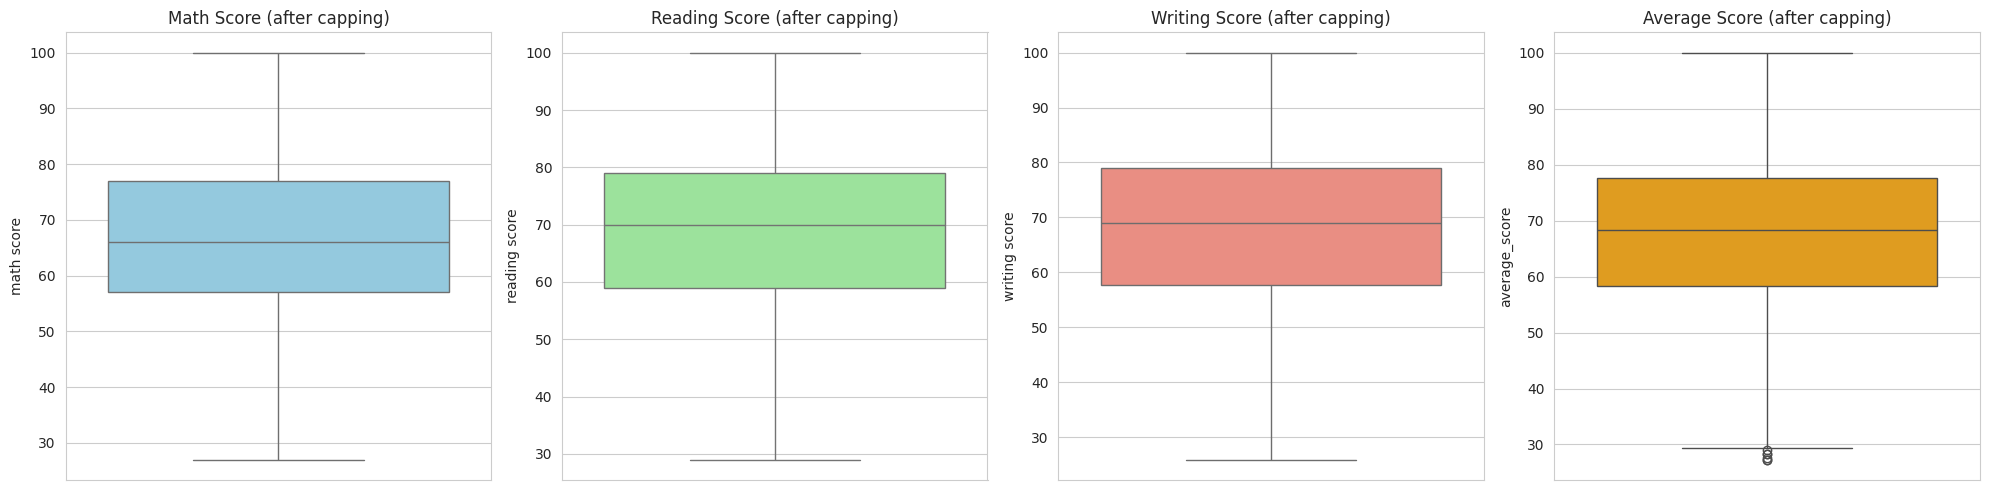

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.boxplot(y=data['math score'], ax=axes[0], color='skyblue')
axes[0].set_title('Math Score (after capping)')

sns.boxplot(y=data['reading score'], ax=axes[1], color='lightgreen')
axes[1].set_title('Reading Score (after capping)')

sns.boxplot(y=data['writing score'], ax=axes[2], color='salmon')
axes[2].set_title('Writing Score (after capping)')

sns.boxplot(y=data['average_score'], ax=axes[3], color='orange')
axes[3].set_title('Average Score (after capping)')

plt.tight_layout()
plt.show()

Univariate — Distributions

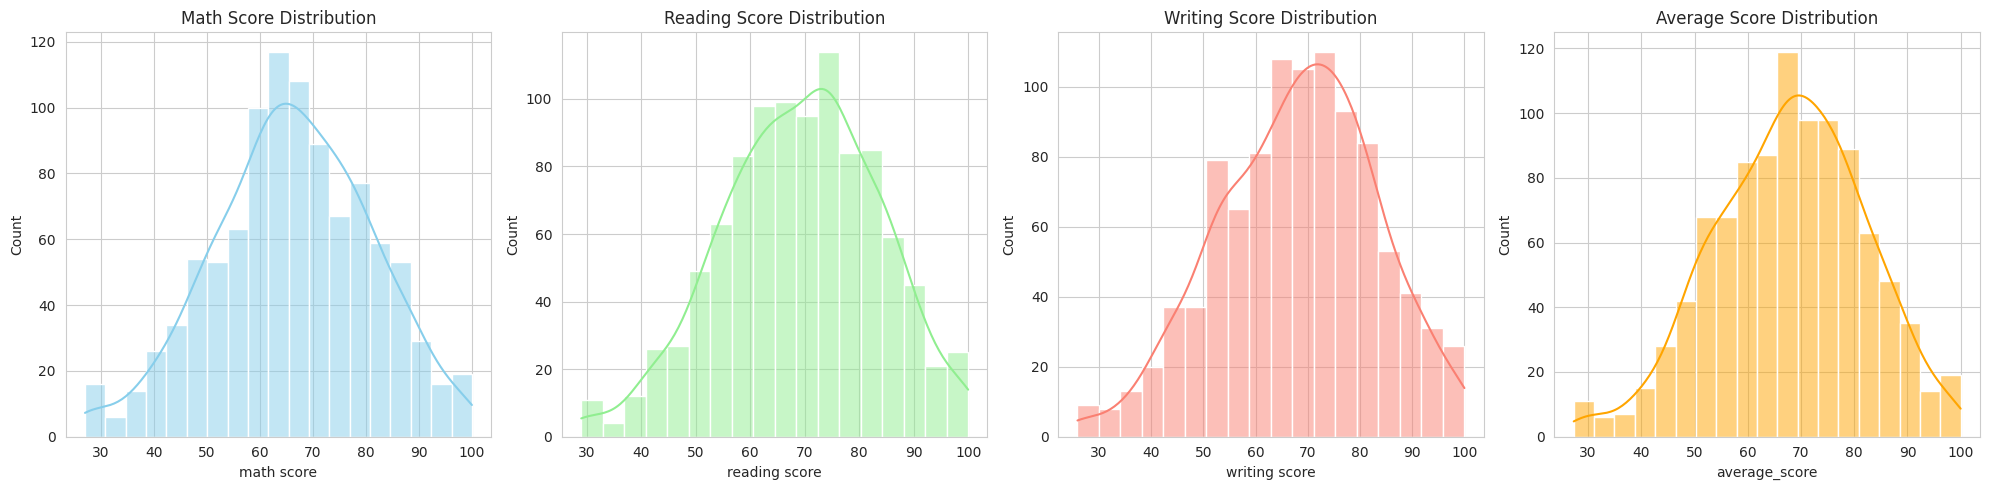

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.histplot(data['math score'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Math Score Distribution')

sns.histplot(data['reading score'], kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Reading Score Distribution')

sns.histplot(data['writing score'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Writing Score Distribution')

sns.histplot(data['average_score'], kde=True, ax=axes[3], color='orange')
axes[3].set_title('Average Score Distribution')

plt.tight_layout()
plt.show()

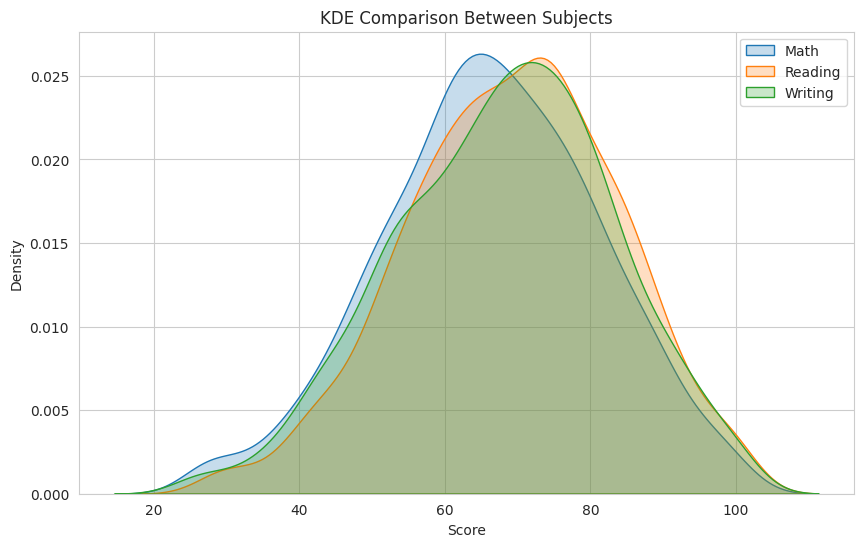

In [14]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data['math score'], label='Math', fill=True)
sns.kdeplot(data['reading score'], label='Reading', fill=True)
sns.kdeplot(data['writing score'], label='Writing', fill=True)

plt.title('KDE Comparison Between Subjects')
plt.xlabel('Score')
plt.legend()
plt.show()

Bivariate — Gender

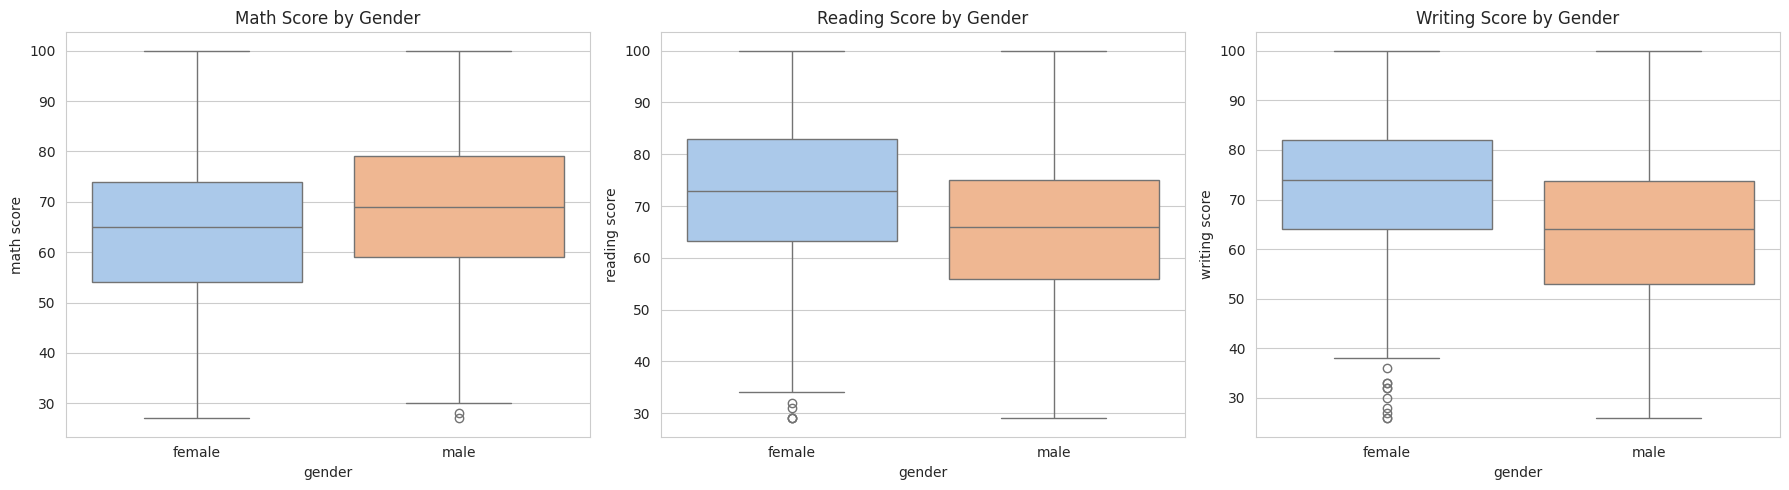

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='gender', y='math score', data=data, ax=axes[0], hue='gender', palette='pastel', legend=False)
axes[0].set_title('Math Score by Gender')

sns.boxplot(x='gender', y='reading score', data=data, ax=axes[1], hue='gender', palette='pastel', legend=False)
axes[1].set_title('Reading Score by Gender')

sns.boxplot(x='gender', y='writing score', data=data, ax=axes[2], hue='gender', palette='pastel', legend=False)
axes[2].set_title('Writing Score by Gender')

plt.tight_layout()
plt.show()

In [16]:
gender_insights = data.groupby('gender')[['math score', 'reading score', 'writing score', 'average_score']].mean()
gender_insights

,math score,reading score,writing score,average_score
gender,,,,
female,63.779923,72.640927,72.503378,69.641409
male,68.728216,65.504149,63.356068,65.862811


Bivariate — Test Prep / Lunch / Parental Education

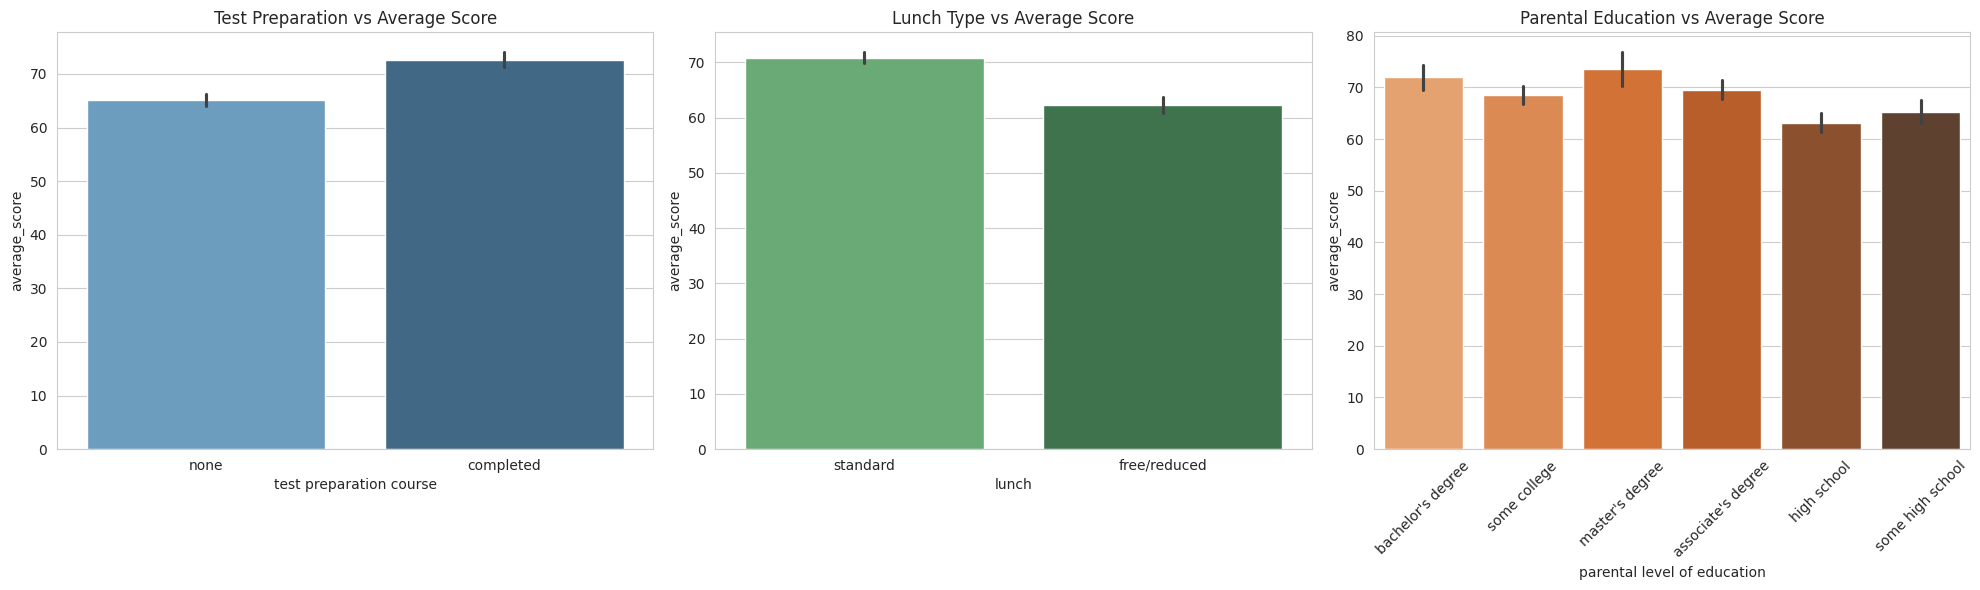

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x='test preparation course', y='average_score', data=data,
            hue='test preparation course', palette='Blues_d', legend=False, ax=axes[0])
axes[0].set_title('Test Preparation vs Average Score')

sns.barplot(x='lunch', y='average_score', data=data,
            hue='lunch', palette='Greens_d', legend=False, ax=axes[1])
axes[1].set_title('Lunch Type vs Average Score')

sns.barplot(x='parental level of education', y='average_score', data=data,
            hue='parental level of education', palette='Oranges_d', legend=False, ax=axes[2])
axes[2].set_title('Parental Education vs Average Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [18]:
prep_group = data.groupby('test preparation course')['average_score'].mean()
lunch_group = data.groupby('lunch')['average_score'].mean()
parent_group = data.groupby('parental level of education')['average_score'].mean().sort_values(ascending=False)

print("=== Average Score by Test Preparation ===")
print(prep_group, "\n")

print("=== Average Score by Lunch Type ===")
print(lunch_group, "\n")

print("=== Average Score by Parental Education (sorted) ===")
print(parent_group)

=== Average Score by Test Preparation ===
test preparation course
completed    72.673184
none         65.113902
Name: average_score, dtype: float64 

=== Average Score by Lunch Type ===
lunch
free/reduced    62.324413
standard        70.844897
Name: average_score, dtype: float64 

=== Average Score by Parental Education (sorted) ===
parental level of education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.570571
some college          68.516040
some high school      65.245345
high school           63.176446
Name: average_score, dtype: float64


Correlation

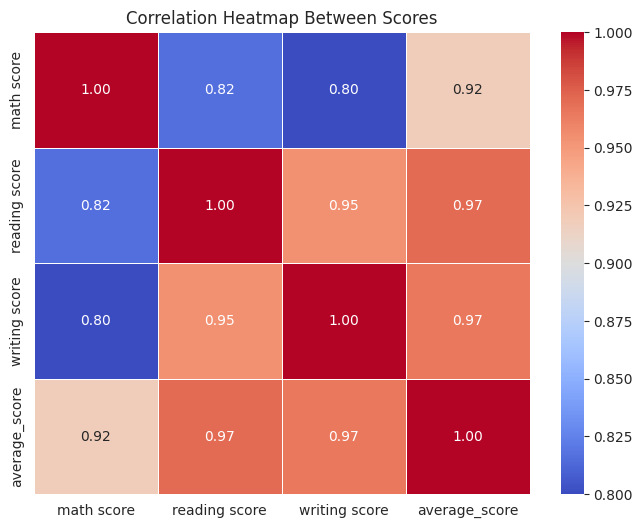

In [19]:
plt.figure(figsize=(8, 6))

correlation = data[['math score', 'reading score', 'writing score', 'average_score']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap Between Scores')
plt.show()

Grade Distribution & At-Risk Students

grade
A     52
B    146
C    261
D    256
F    285
Name: count, dtype: int64


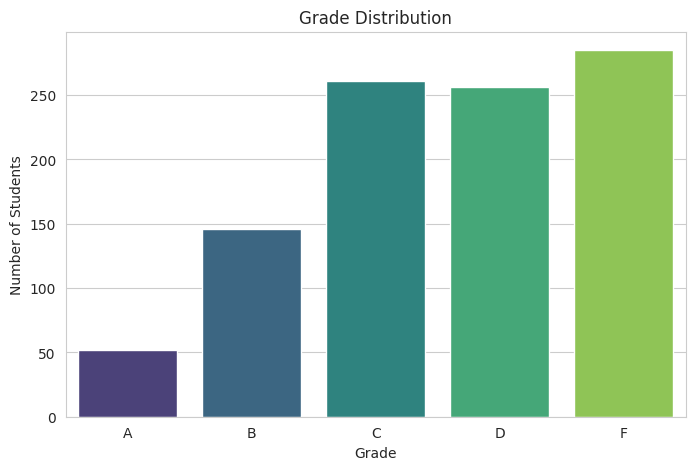

In [20]:
grade_dist = data['grade'].value_counts().sort_index()
print(grade_dist)

plt.figure(figsize=(8, 5))
sns.barplot(x=grade_dist.index, y=grade_dist.values, hue=grade_dist.index, palette='viridis', legend=False)
plt.title('Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.show()

In [21]:
at_risk_students = data[
    (data['average_score'] < 60) &
    (data['test preparation course'] == 'none') &
    (data['lunch'] == 'free/reduced')
]

at_risk_pct = (len(at_risk_students) / len(data)) * 100

print(f"Number of at-risk students needing academic support: {len(at_risk_students)}")
print(f"At-risk students percentage (average_score < 60, overall): {(len(data[data['average_score'] < 60]) / len(data)) * 100:.2f}%")

Number of at-risk students needing academic support: 117
At-risk students percentage (average_score < 60, overall): 28.50%


## Key Insights Summary

1. **Data quality:** No missing values, no duplicates — the dataset was clean going in.
2. **Outliers:** A small number of low-end outliers existed mainly in math scores; handled via IQR capping rather than removal, to preserve sample size.
3. **Distributions:** All three subject scores are roughly normal, slightly left-skewed, with reading/writing more tightly clustered than math.
4. **Gender:** Females lead in reading/writing; males lead slightly in math.
5. **Test preparation:** Completing the prep course is associated with a consistent score boost across all subjects.
6. **Socioeconomic factors:** Lunch type (a proxy for economic status) and parental education level both show a clear positive relationship with average score.
7. **Correlation:** Reading and writing scores move almost together (r ≈ 0.95); math is a comparatively more independent skill.
8. **At-risk group:** Students combining low scores, no test prep, and free/reduced lunch form a clearly identifiable at-risk segment.

## Recommendations

1. **Test Preparation Course:** Students who completed the course scored higher on average. → Encourage/require test prep courses before exams.
2. **Lunch Type:** Students with standard lunch outperformed those with free/reduced lunch, reflecting a socioeconomic/nutrition effect. → Support school nutrition programs for lower-income students.
3. **Parental Education:** Higher parental education levels correlate with higher average scores. → Provide additional academic support for students with less-educated parents.
4. **Grade Distribution:** Most students fall into grades C and D. → Focus remedial programs on C/D students to raise the overall average.
5. **Targeted Intervention:** Prioritize the identified at-risk group (low score + no test prep + free/reduced lunch) for combined academic and nutritional support programs, since these factors compound rather than act independently.